In [1]:
# In this code, we use a pre-trained ResNet-50 model from torchvision
# to classify dog images, train on GPU if available, evaluate on validation data,
# and display the predicted class on a new image with matplotlib.

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt

from PIL import Image

In [2]:

# ----------------------------
# Device
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:

# ----------------------------
# Define data directory
# ----------------------------
data_dir = "data/dogs"

In [4]:

# ----------------------------
# Transforms
# ----------------------------
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

valid_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Separate transform just for displaying the image nicely
display_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224)
])

In [5]:
# ----------------------------
# Datasets and loaders
# ----------------------------
train_dataset = datasets.ImageFolder(data_dir + "/train", transform=train_transforms)
valid_dataset = datasets.ImageFolder(data_dir + "/valid", transform=valid_transforms)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

valid_loader = torch.utils.data.DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [6]:

# ----------------------------
# Model
# ----------------------------
weights = torchvision.models.ResNet50_Weights.DEFAULT
model = torchvision.models.resnet50(weights=weights)
model.fc = torch.nn.Linear(2048, 2)
model = model.to(device)


In [7]:

# ----------------------------
# Loss and optimizer
# ----------------------------
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [8]:
# ----------------------------
# Train
# ----------------------------
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch: {epoch + 1}, Loss: {avg_loss:.4f}")

Epoch: 1, Loss: 0.8345
Epoch: 2, Loss: 0.6573
Epoch: 3, Loss: 0.6022
Epoch: 4, Loss: 0.5956
Epoch: 5, Loss: 0.5635
Epoch: 6, Loss: 0.5182
Epoch: 7, Loss: 0.5133
Epoch: 8, Loss: 0.4885
Epoch: 9, Loss: 0.4354
Epoch: 10, Loss: 0.4662


In [9]:
# ----------------------------
# Validation
# ----------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy on validation data: {accuracy:.2f}%")


Accuracy on validation data: 100.00%


In [10]:

# ----------------------------
# Inference on a new image
# ----------------------------
image_path = "test_data/img.png"
image = Image.open(image_path).convert("RGB")

# Tensor for model input
image_tensor = valid_transforms(image).unsqueeze(0).to(device)

# Separate version for display
image_to_show = display_transforms(image)

# Predict
model.eval()
with torch.no_grad():
    output = model(image_tensor)
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    predicted_class_index = torch.argmax(probabilities).item()

class_labels = train_dataset.classes
predicted_class_label = class_labels[predicted_class_index]
confidence = probabilities[predicted_class_index].item()

print(f"Predicted class label: {predicted_class_label}")
print(f"Confidence: {confidence:.4f}")



Predicted class label: husky
Confidence: 0.6630


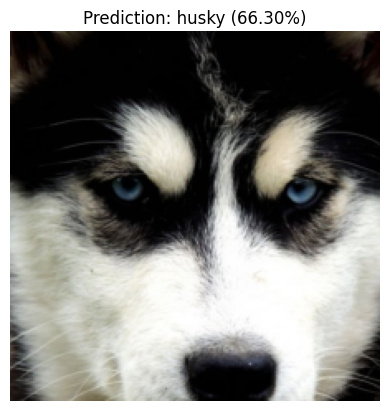

done


In [11]:
# ----------------------------
# Show image with prediction
# ----------------------------
plt.imshow(image_to_show)
plt.title(f"Prediction: {predicted_class_label} ({confidence:.2%})")
plt.axis("off")
plt.show()
print("done")

In [12]:
print("hi")

hi
